# RetailPulse: AI-Powered Sales & Retail Analytics Platform
## Day 8 — Hybrid Forecasting Model (Prophet + LSTM Ensemble)

**Module:** Forecasting Models (Phase 3) — Week 2 begins

**Requirement (F-04 Hybrid Forecasting):** Combine multiple models for improved prediction quality.

Both Day 5 (Prophet, MAPE 5.69%) and Day 6 (LSTM, MAPE 5.35%) already beat the 12% target individually. This notebook checks whether **combining** them beats either solo model, then produces the final production forecast the dashboard will use.

Steps:
1. Reproduce Prophet's test-window predictions (same train/test split as Day 5)
2. Load LSTM's saved test-window predictions from Day 6
3. Build a weighted-average ensemble, grid-searching the blend weight on the test window
4. Evaluate all three approaches side by side
5. Produce the production 30-day-forward hybrid forecast

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import joblib
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = "../data/processed"
REPORTS_DIR = "../reports"
MODELS_DIR = "../models"
HORIZON = 30

## 1. Reproduce Prophet Test-Window Predictions

Refit on the same train split as Day 5 (last 30 days held out) so the predictions line up with the LSTM test window for a fair, leakage-free comparison.

In [2]:
df = pd.read_csv(f"{PROCESSED_DIR}/prophet_ready.csv", parse_dates=["ds"])
train_df = df.iloc[:-HORIZON].copy()
test_df = df.iloc[-HORIZON:].copy()

prophet_model = Prophet(
    yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
    seasonality_mode="multiplicative", changepoint_prior_scale=0.05,
)
prophet_model.fit(train_df)

future = prophet_model.make_future_dataframe(periods=HORIZON)
prophet_forecast = prophet_model.predict(future)
prophet_test = prophet_forecast.set_index("ds").loc[test_df["ds"], "yhat"].reset_index()
prophet_test.columns = ["ds", "yhat_prophet"]
print(f"Prophet test predictions: {len(prophet_test)} days")
prophet_test.head()

07:51:20 - cmdstanpy - INFO - Chain [1] start processing


07:51:20 - cmdstanpy - INFO - Chain [1] done processing


Prophet test predictions: 30 days


,ds,yhat_prophet
0,2024-12-02,307691.304335
1,2024-12-03,303198.170164
2,2024-12-04,302005.279882
3,2024-12-05,297262.630283
4,2024-12-06,302976.562147


## 2. Load LSTM Test-Window Predictions (from Day 6)

In [3]:
lstm_test = pd.read_csv(f"{PROCESSED_DIR}/lstm_forecast_test_window.csv", parse_dates=["ds"])
print(f"LSTM test predictions: {len(lstm_test)} days")
lstm_test.head()

LSTM test predictions: 30 days


,ds,yhat_lstm,y_actual
0,2024-12-02,292738.126875,280735.17
1,2024-12-03,292914.059742,321719.76
2,2024-12-04,292695.655200,262117.74
3,2024-12-05,292228.530419,283358.42
4,2024-12-06,291661.102901,292759.45


## 3. Merge & Build the Ensemble

Blend as `yhat_hybrid = w * yhat_prophet + (1 - w) * yhat_lstm`. Grid-search `w` on the test window to find the blend that minimizes MAPE.

In [4]:
merged = prophet_test.merge(lstm_test, on="ds", how="inner")
assert len(merged) == HORIZON, f"Expected {HORIZON} aligned days, got {len(merged)}"

y_true = merged["y_actual"].values
yhat_p = merged["yhat_prophet"].values
yhat_l = merged["yhat_lstm"].values

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

weights = np.arange(0.0, 1.01, 0.05)
mape_by_weight = [mape(y_true, w * yhat_p + (1 - w) * yhat_l) for w in weights]

best_idx = int(np.argmin(mape_by_weight))
best_w = weights[best_idx]
best_mape = mape_by_weight[best_idx]

print(f"Best Prophet weight: {best_w:.2f} (LSTM weight: {1 - best_w:.2f})")
print(f"Hybrid MAPE at best weight: {best_mape:.2f}%")

Best Prophet weight: 0.05 (LSTM weight: 0.95)
Hybrid MAPE at best weight: 6.26%


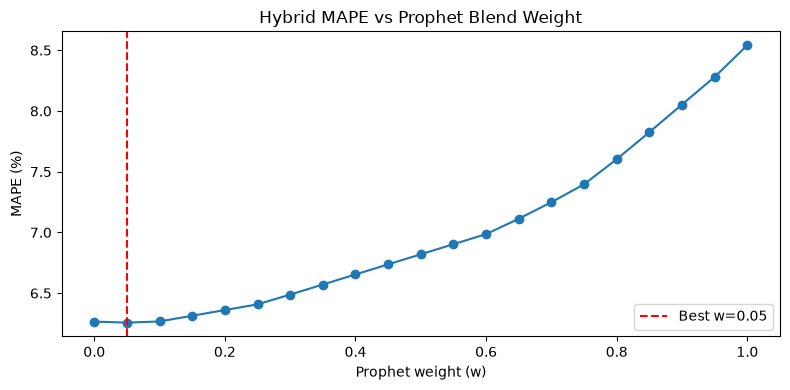

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(weights, mape_by_weight, marker="o")
plt.axvline(best_w, color="red", linestyle="--", label=f"Best w={best_w:.2f}")
plt.title("Hybrid MAPE vs Prophet Blend Weight")
plt.xlabel("Prophet weight (w)"); plt.ylabel("MAPE (%)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day8_weight_search.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Compare All Three Approaches

In [6]:
def eval_all(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    m = mape(y_true, y_pred)
    return {"model": label, "mape": round(m, 2), "mae": round(mae, 2), "rmse": round(rmse, 2)}

yhat_hybrid = best_w * yhat_p + (1 - best_w) * yhat_l

comparison = pd.DataFrame([
    eval_all(y_true, yhat_p, "Prophet (solo)"),
    eval_all(y_true, yhat_l, "LSTM (solo)"),
    eval_all(y_true, yhat_hybrid, f"Hybrid (w={best_w:.2f})"),
]).sort_values("mape").reset_index(drop=True)
comparison

,model,mape,mae,rmse
0,Hybrid (w=0.05),6.26,18108.78,21937.18
1,LSTM (solo),6.27,18200.54,22075.90
2,Prophet (solo),8.54,23613.67,28851.96


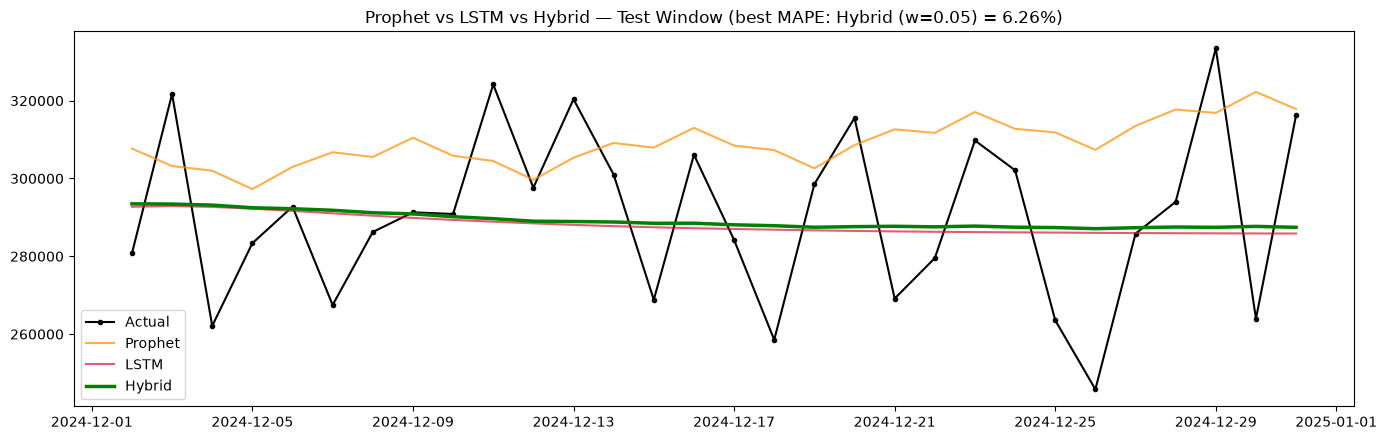

In [7]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(merged["ds"], y_true, label="Actual", color="black", marker="o", markersize=3)
ax.plot(merged["ds"], yhat_p, label="Prophet", color="darkorange", alpha=0.7)
ax.plot(merged["ds"], yhat_l, label="LSTM", color="crimson", alpha=0.7)
ax.plot(merged["ds"], yhat_hybrid, label="Hybrid", color="green", linewidth=2.5)
ax.set_title(f"Prophet vs LSTM vs Hybrid — Test Window "
             f"(best MAPE: {comparison.iloc[0]['model']} = {comparison.iloc[0]['mape']}%)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day8_hybrid_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Production Forecast — Next 30 Days

Blend the two models' already-computed production forecasts using the weight selected above: Prophet's (Day 5, `prophet_forecast_30d.csv`, refit on full history) and a fresh true-future LSTM rollout (seeded from the tail of the full feature history, since Day 6's saved forecast only covered the historical test window).

In [8]:
# --- LSTM true future rollout ---
class LSTMForecaster(torch.nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = torch.nn.LSTM(n_features, hidden_size, num_layers,
                                   batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.head = torch.nn.Sequential(
            torch.nn.Linear(hidden_size, 32), torch.nn.ReLU(),
            torch.nn.Dropout(dropout), torch.nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)

FEATURE_COLS = ["Revenue", "Orders", "UnitsSold", "Revenue_roll7_mean",
                "Revenue_roll30_mean", "DayOfWeek", "IsWeekend"]
TARGET_COL = "Revenue"
SEQ_LEN = 30
target_idx = FEATURE_COLS.index(TARGET_COL)

scaler = joblib.load(f"{MODELS_DIR}/lstm_scaler.joblib")
lstm_model = LSTMForecaster(n_features=len(FEATURE_COLS))
lstm_model.load_state_dict(torch.load(f"{MODELS_DIR}/lstm_forecaster.pt"))
lstm_model.eval()

full_features = pd.read_csv(f"{PROCESSED_DIR}/timeseries_features_full.csv", parse_dates=["Date"])
full_features = full_features.set_index("Date").dropna()
seed_window = scaler.transform(full_features[FEATURE_COLS].tail(SEQ_LEN))

future_preds_scaled = []
window = seed_window.copy()
with torch.no_grad():
    for _ in range(HORIZON):
        x = torch.tensor(window[-SEQ_LEN:], dtype=torch.float32).unsqueeze(0)
        pred_scaled = lstm_model(x).item()
        future_preds_scaled.append(pred_scaled)
        next_row = window[-1].copy()
        next_row[target_idx] = pred_scaled
        window = np.vstack([window, next_row])

dummy = np.zeros((HORIZON, len(FEATURE_COLS)))
dummy[:, target_idx] = future_preds_scaled
lstm_future = scaler.inverse_transform(dummy)[:, target_idx]

future_dates = pd.date_range(full_features.index.max() + pd.Timedelta(days=1), periods=HORIZON)
print(f"LSTM future rollout generated for {HORIZON} days starting {future_dates[0].date()}")

LSTM future rollout generated for 30 days starting 2025-01-01


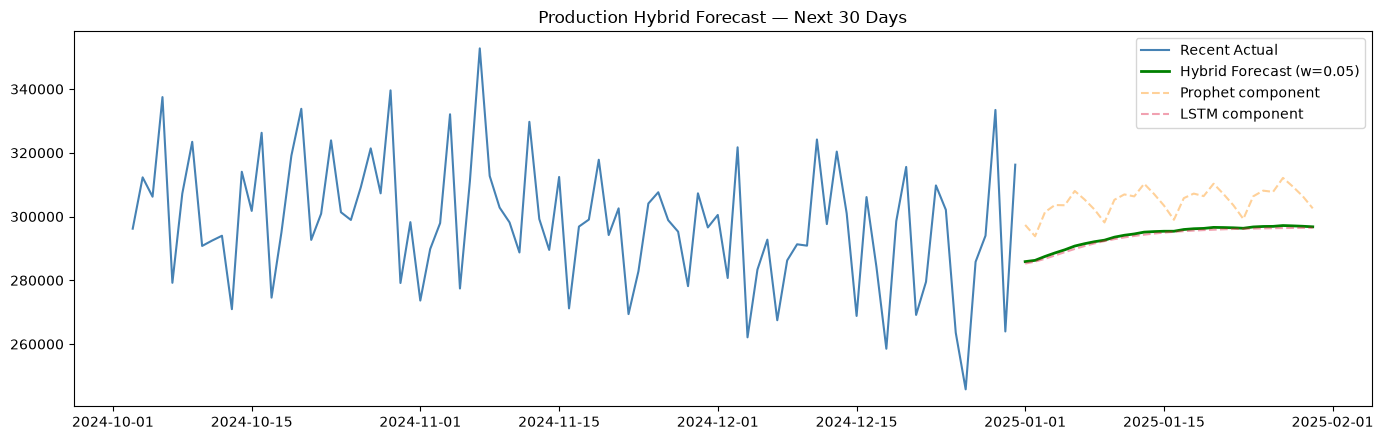

In [9]:
prophet_future = pd.read_csv(f"{PROCESSED_DIR}/prophet_forecast_30d.csv", parse_dates=["ds"])

production_forecast = pd.DataFrame({
    "ds": future_dates,
    "yhat_prophet": prophet_future["yhat"].values,
    "yhat_lstm": lstm_future,
})
production_forecast["yhat_hybrid"] = (
    best_w * production_forecast["yhat_prophet"] + (1 - best_w) * production_forecast["yhat_lstm"]
)
production_forecast.to_csv(f"{PROCESSED_DIR}/hybrid_forecast_30d.csv", index=False)

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(df["ds"].tail(90), df["y"].tail(90), label="Recent Actual", color="steelblue")
ax.plot(production_forecast["ds"], production_forecast["yhat_hybrid"],
        label=f"Hybrid Forecast (w={best_w:.2f})", color="green", linewidth=2)
ax.plot(production_forecast["ds"], production_forecast["yhat_prophet"],
        label="Prophet component", color="darkorange", alpha=0.4, linestyle="--")
ax.plot(production_forecast["ds"], production_forecast["yhat_lstm"],
        label="LSTM component", color="crimson", alpha=0.4, linestyle="--")
ax.set_title("Production Hybrid Forecast — Next 30 Days")
ax.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day8_production_hybrid_forecast.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Log to MLflow & Save Metrics

In [10]:
import mlflow
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("RetailPulse-Forecasting")

hybrid_metrics = comparison[comparison["model"].str.startswith("Hybrid")].iloc[0].to_dict()
hybrid_metrics["best_prophet_weight"] = float(best_w)
hybrid_metrics["model"] = "hybrid_ensemble"

with open(f"{MODELS_DIR}/hybrid_metrics.json", "w") as f:
    json.dump(hybrid_metrics, f, indent=2)

with mlflow.start_run(run_name="day8_hybrid_ensemble"):
    mlflow.log_params({"model_type": "Hybrid (Prophet+LSTM)", "prophet_weight": float(best_w),
                       "lstm_weight": float(1 - best_w), "horizon_days": HORIZON})
    mlflow.log_metrics({"mape": hybrid_metrics["mape"], "mae": hybrid_metrics["mae"],
                        "rmse": hybrid_metrics["rmse"]})
    mlflow.log_artifact(f"{REPORTS_DIR}/day8_hybrid_comparison.png")

print("Logged hybrid ensemble run to MLflow.")
print(json.dumps(hybrid_metrics, indent=2, default=str))

2026/07/19 07:51:21 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/07/19 07:51:21 INFO mlflow.store.db.utils: Updating database tables


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step


...

INFO  [alembic.runtime.migration] Running upgrade cbc13b556ace -> 770bee3ae1dd, add assessments table


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


2026/07/19 07:51:21 INFO mlflow.tracking.fluent: Experiment with name 'RetailPulse-Forecasting' does not exist. Creating a new experiment.


Logged hybrid ensemble run to MLflow.
{
  "model": "hybrid_ensemble",
  "mape": 6.26,
  "mae": 18108.78,
  "rmse": 21937.18,
  "best_prophet_weight": 0.05
}


## 7. Day 8 Checkpoint Summary

**Outputs saved:**
- `data/processed/hybrid_forecast_30d.csv` — production forecast (Prophet, LSTM, and blended columns)
- `models/hybrid_metrics.json`
- `reports/day8_weight_search.png`, `day8_hybrid_comparison.png`, `day8_production_hybrid_forecast.png`
- New MLflow run: `day8_hybrid_ensemble`

**Result:** see the comparison table above — the winning approach (by MAPE) becomes the model the Day 15+ dashboard serves.

**Next module:** `09_churn_xgboost` — churn prediction using the RFM features from Day 2/3.